In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
data_train=pd.read_csv('T-R-train.csv')
data_train.head()
data_test=pd.read_csv('T-R-test.csv')
x_test=data_test.loc[:,'T']
y_test=data_test.loc[:,'rate']

In [2]:
x_train=data_train.loc[:,'T']
y_train=data_train.loc[:,'rate']

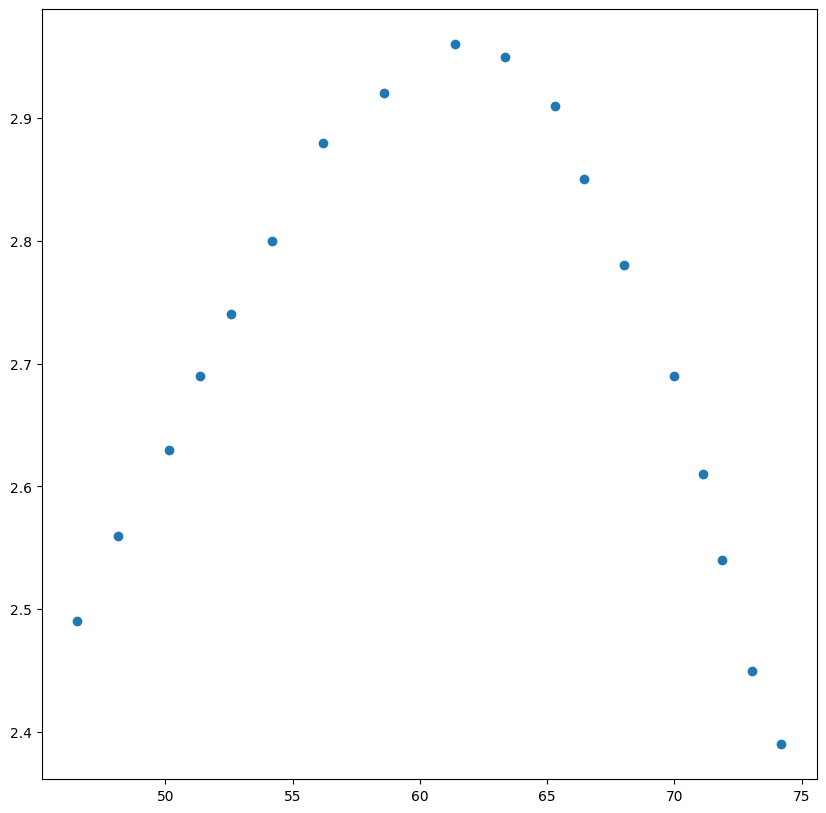

In [3]:
fig1=plt.figure(figsize = (10,10))
plt.scatter(x_train,y_train)
plt.show()

In [4]:
from sklearn.linear_model import LinearRegression
lr1=LinearRegression()
x_train=np.array(x_train).reshape(-1,1)
x_test=np.array(x_test).reshape(-1,1)
lr1.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [5]:
data_test=pd.read_csv('T-R-test.csv')
x_test=data_test.loc[:,'T']
y_test=data_test.loc[:,'rate']

In [6]:
y_train_pred=lr1.predict(x_train)
y_test_pred=lr1.predict(x_test)

ValueError: Expected a 2-dimensional container but got <class 'pandas.Series'> instead. Pass a DataFrame containing a single row (i.e. single sample) or a single column (i.e. single feature) instead.

In [ ]:
from sklearn.metrics import r2_score
r2_train=r2_score(y_train,y_train_pred)
r2_pred=r2_score(y_test,y_test_pred)

print(r2_train,r2_pred)

In [ ]:
x_range=np.linspace(40,90,300).reshape(-1,1)
y_range_predict=lr1.predict(x_range)
fig1=plt.figure(figsize = (10,10))
plt.scatter(x_range,y_range_predict)
plt.scatter(x_train,y_train)
plt.show()

In [ ]:
from sklearn.preprocessing import PolynomialFeatures
poly=PolynomialFeatures(degree=2)
x_2_train=poly.fit_transform(x_train)
x_2_test=poly.fit_transform(x_test)

In [ ]:
lr2=LinearRegression()
lr2.fit(x_2_train,y_train)
y_train_pred=lr2.predict(x_2_train)
y_test_pred=lr2.predict(x_2_test)
r2_train2=r2_score(y_train,y_train_pred)
r2_pred2=r2_score(y_test,y_test_pred)
print(r2_train2,r2_pred2)

In [ ]:
x_2_range=np.linspace(40,90,300).reshape(-1,1)
x_2_range=poly.transform(x_2_range)
y_2_range_predict=lr2.predict(x_2_range)
fig2=plt.figure(figsize = (10,10))
plt.plot(x_range,y_2_range_predict)
plt.scatter(x_train,y_train)
plt.scatter(x_test,y_test)
plt.show()